In [3]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np 
import torch
from torchvision import transforms

# Transformador para convertir imágenes PIL a tensores normalizados
transform = transforms.Compose(
    [
        transforms.ToPILImage(), 
        transforms.Resize((224, 224)),
        transforms.ToTensor(),  # convierte PIL o np.array a [C, H, W] y escala a [0, 1]
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Cargar el modelo completo
model_rot = torch.load("mobilenet_angle_full_model.pt",weights_only=False, map_location=torch.device("cpu"))
model_rot.eval()


# Cargar el model_yoloo completo
model_yolo = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best_v180.pt")  # Cambia por "runs/detect/train/weights/best.pt"

import cv2
import numpy as np

def rotar_imagen_cv2(img, angulo):
    """
    Rota una imagen con OpenCV alrededor del centro y ajusta el tamaño del canvas.

    Args:
        img (np.ndarray): Imagen cargada con cv2.
        angulo (float): Ángulo de rotación en grados (positivo: antihorario).

    Returns:
        np.ndarray: Imagen rotada.
    """
    (h, w) = img.shape[:2]
    centro = (w // 2, h // 2)

    # Matriz de rotación
    M = cv2.getRotationMatrix2D(centro, angulo, 1.0)

    # Calcular el nuevo tamaño del canvas para que quepa la imagen completa
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    nuevo_ancho = int((h * sin) + (w * cos))
    nuevo_alto = int((h * cos) + (w * sin))

    # Ajustar la matriz de rotación para el nuevo centro
    M[0, 2] += (nuevo_ancho / 2) - centro[0]
    M[1, 2] += (nuevo_alto / 2) - centro[1]

    # Aplicar rotación
    img_rotada = cv2.warpAffine(img, M, (nuevo_ancho, nuevo_alto), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return img_rotada




0: 416x640 None19.2ms
Speed: 1.6ms preprocess, 19.2ms inference, 3.9ms postprocess per image at shape (1, 3, 416, 640)
[[3.2168561e+02 ... 5.6259476e-02]
 ...
 [3.2390616e+02 ... 6.7788303e-02]]
0.97331995


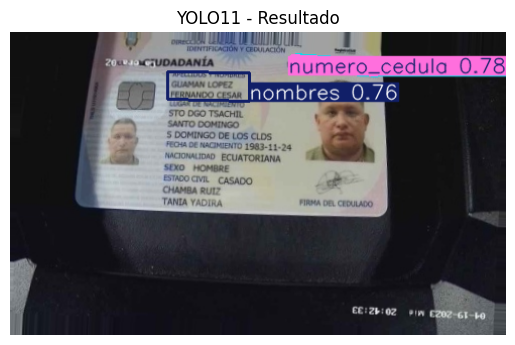

In [84]:
SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Cedula_Guayaquil/ImagenCedula_02C3Ivf.jpg"  # Ruta de la imagen
image = cv2.imread(SOURCE_PATH)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img = transform(image).unsqueeze(0)   # Añadir batch dimension

with torch.no_grad():
    pred = model_rot(img)
    pred_angle = pred.item() * 180 / np.pi  # Convertir a grados

image=rotar_imagen_cv2(image,-pred_angle)

# Cargar imagen con PIL
# Realizar inferencia
results = model_yolo(image,conf=0.7)
# Mostrar resultados usando PIL
for result in results:
    # result.plot() devuelve una imagen NumPy (BGR), la convertimos a RGB para PIL
    img_array = result.plot()[:, :, ::-1]
    data=result.obb.xywhr.cpu().numpy()
    points=result.obb.xyxyxyxy.cpu().numpy()
    print(data)
    print(np.degrees(data[1][-1]))
    #np.degrees(data[1][-1])-90
    if np.degrees(data[1][-1])>45:
        angle_corr=np.degrees(data[1][-1])-90
    else:
        angle_corr=np.degrees(data[1][-1])
    result_image = rotar_imagen_cv2(img_array,angle_corr)
    img_rot=rotar_imagen_cv2(image,angle_corr)
    img_rot = cv2.cvtColor(img_rot, cv2.COLOR_BGR2RGB)
    # Mostrar usando matplotlib
    plt.imshow(img_array)
    plt.axis('off')
    plt.title("YOLO11 - Resultado")
    plt.show()

In [85]:
import cv2
import numpy as np

def recorte_desde_4_puntos(imagen, puntos, expand_ratio=0.2, scale=1.0):
    """
    Recorta una región definida por 4 puntos, la alinea (ángulo 0), 
    permite expandir la caja y escalar el resultado.

    Args:
        imagen (np.ndarray): Imagen original.
        puntos (list): Lista de 4 puntos [[x1,y1], [x2,y2], [x3,y3], [x4,y4]].
        expand_ratio (float): Porcentaje para expandir la caja (ej: 0.1 = 10%).
        scale (float): Escala del resultado (ej: 2.0 = el doble de tamaño).

    Returns:
        np.ndarray: Imagen recortada, recta y escalada.
    """
    # Convertir a float32
    pts = np.array(puntos, dtype="float32")

    # Ordenar los puntos (tl, tr, br, bl)
    def ordenar_puntos(pts):
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]  # top-left
        rect[2] = pts[np.argmax(s)]  # bottom-right

        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # top-right
        rect[3] = pts[np.argmax(diff)]  # bottom-left
        return rect

    rect = ordenar_puntos(pts)
    (tl, tr, br, bl) = rect

    # Expandir caja si se solicita
    if expand_ratio > 0:
        centro = np.mean(rect, axis=0)
        rect = centro + (rect - centro) * (1 + expand_ratio)

        # Limitar a los bordes de la imagen
        h, w = imagen.shape[:2]
        rect[:, 0] = np.clip(rect[:, 0], 0, w - 1)
        rect[:, 1] = np.clip(rect[:, 1], 0, h - 1)

    # Recalcular dimensiones del recorte alineado
    (tl, tr, br, bl) = rect
    ancho_sup = np.linalg.norm(tr - tl)
    ancho_inf = np.linalg.norm(br - bl)
    max_ancho = int(max(ancho_sup, ancho_inf))

    alto_izq = np.linalg.norm(bl - tl)
    alto_der = np.linalg.norm(br - tr)
    max_alto = int(max(alto_izq, alto_der))

    # Aplicar escala
    max_ancho = int(max_ancho * scale)
    max_alto = int(max_alto * scale)

    # Puntos destino en el espacio plano y escalado
    dst = np.array([
        [0, 0],
        [max_ancho - 1, 0],
        [max_ancho - 1, max_alto - 1],
        [0, max_alto - 1]
    ], dtype="float32")

    # Transformación de perspectiva
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(imagen, M, (max_ancho, max_alto))

    return warped


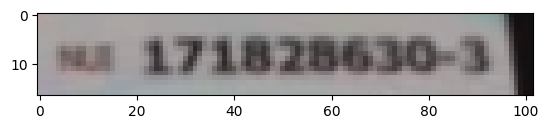

In [86]:
recortado_rotado = recorte_desde_4_puntos(image, points[0])
img_result=Image.fromarray(recortado_rotado)
plt.imshow(img_result)

In [87]:
from paddleocr import PaddleOCR
from PIL import Image
import json
ocr = PaddleOCR(lang='en')  # También puedes usar lang='en', 'ch', etc.

Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in C:\Users\jeff_\.paddlex\official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 1999.83it/s]
Creating model: ('UVDoc', None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in C:\Users\jeff_\.paddlex\official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 2002.05it/s]
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in C:\Users\jeff_\.paddlex\official_models.
Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in C:\Users\jeff_\.paddlex\official_models.
Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 2000.78it/s]
Creating model: ('PP-OCRv5_server_rec', 

In [88]:
result = ocr.predict(recortado_rotado)
print(len(result[0]))
print(result[0].keys())
print(result[0]["rec_texts"])
print(result[0]["rec_scores"])
print(result[0]["textline_orientation_angles"])

13
dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'rec_texts', 'rec_scores', 'rec_polys', 'textline_orientation_angles', 'rec_boxes'])
['171828630-3']
[0.8500861525535583]
[0]
